In [60]:
# GitHub Commands
# git pull (to get the latest code)

# git add Project3/FinalProject.ipynb
# git commit -m "text"
# git push

# The Problem & Dataset

We’re investigating the effects primarily online classes have had on student success since before remote learning was prominent in schools. We’re specifically looking for whether graduation outcomes overall have increased or decreased as online classes have become a more prominent method of instruction.

We seek to investigate the relationship between prominent online schooling and student performance in college, if one exists.

This problem matters because it gives us a better understanding of how distance learning can support or hurt students and the rise of distance learning after COVID-19. The results from this project can be used to identify whether or not distance learning is beneficial for students and what institutions are using distance learning most effectively.

We are using a dataset derived from IPEDS Data Center with features related to our problem. Our dataset accounts for public four-year institutions across multiple years. The dataset includes data to identify institutions, institution demographics, and data about the presence of fully remote learning options. 

The dataset includes the following features:

- unitid - unique institutional ID number
- institution_name - name of the college or university
- year - year the data was recorded
- avg_net_price - average net price of attendance for students
- grad_rate_150pct_4yr - 4-year institution graduation rate measured at 150% of normal completion time
- hispanic_count - number of Hispanic students enrolled
- black_count - number of Black students enrolled
- white_count - number of White students enrolled
- hispanic_share - proportion of enrolled students who are Hispanic
- black_share - proportion of enrolled students who are Black
- white_share - proportion of enrolled students who are White
- distance_only_count - number of students enrolled exclusively in distance education
- distance_only_share_imputed - imputed proportion of students enrolled exclusively in distance education
- distance_data_available - indicator for whether distance education data is available
- control_of_institution - control type of the institution
- level_of_institution - institution level
- sector_of_institution - institutional sector classification

Variable Notes
- grad_rate_150pct_4yr: Because this is measured at 150% of normal completion time. This means completion within about 6 years, not 4 years.
- avg_net_price: Represents average net cost after financial aid
- In general variables related to distance education only count students who are fully remote learners. Students who take a mix of in-person and remote classes are not represented in these columns.

# Data Preprocessing & Assumptions

In [61]:
# Import Packages
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

### Load Data

In [62]:
# Load the data
df = pd.read_csv("education_data.csv")

### Understanding the Dataset

In [63]:
df.head()

,unitid,institution_name,year,avg_net_price,grad_rate_150pct_4yr,hispanic_count,black_count,white_count,hispanic_share,black_share,white_share,distance_only_count,distance_only_share_imputed,distance_data_available,control_of_institution,level_of_institution,sector_of_institution
0,100654,Alabama A & M University,2017,15812,0.239571,51,5361,232,0.008499,0.893351,0.038660,121,NaN,NaN,Public,Four or more years,"Public, 4-year or above"
1,100654,Alabama A & M University,2020,15373,0.286573,62,5140,111,0.010373,0.859963,0.018571,1869,0.312699,NaN,Public,Four or more years,"Public, 4-year or above"
2,100654,Alabama A & M University,2023,14064,0.287383,88,5664,128,0.013305,0.856365,0.019353,406,0.061385,1.0,Public,Four or more years,"Public, 4-year or above"
3,100663,University of Alabama at Birmingham,2017,17016,0.529188,673,4435,12530,0.032198,0.212181,0.599464,4917,NaN,NaN,Public,Four or more years,"Public, 4-year or above"
4,100663,University of Alabama at Birmingham,2020,16978,0.612019,1050,4746,12966,0.046536,0.210344,0.574658,6346,0.281257,NaN,Public,Four or more years,"Public, 4-year or above"


In [64]:
df.describe()

,unitid,year,avg_net_price,grad_rate_150pct_4yr,hispanic_count,black_count,white_count,hispanic_share,black_share,white_share,distance_only_count,distance_only_share_imputed,distance_data_available
count,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1713.000000,1150.000000,593.0
mean,192983.009924,2020.052539,13961.921191,0.512358,2148.614711,1371.000584,6891.969060,0.132371,0.137457,0.550965,3035.262113,0.283051,1.0
std,67934.900445,2.464618,4318.328944,0.176012,3924.011600,1806.542353,7155.016284,0.145954,0.193450,0.238125,5851.533719,0.254512,0.0
min,100654.000000,2017.000000,306.000000,0.029412,1.000000,0.000000,4.000000,0.000193,0.000000,0.006421,0.000000,0.000000,1.0
25%,155681.000000,2017.000000,11256.000000,0.387368,221.000000,199.000000,1645.000000,0.044495,0.035056,0.424387,407.000000,0.097285,1.0
50%,187985.000000,2020.000000,13958.000000,0.508547,686.000000,746.000000,4414.000000,0.077318,0.069881,0.609518,1146.000000,0.205723,1.0
75%,216764.000000,2023.000000,16736.000000,0.630305,2206.000000,1824.000000,9444.000000,0.157435,0.143514,0.740911,3014.000000,0.378310,1.0
max,498571.000000,2023.000000,29785.000000,1.000000,38139.000000,17417.000000,39653.000000,0.956732,0.950933,0.923513,53815.000000,1.000000,1.0


In [65]:
df.shape

(1713, 17)

In [66]:
df.dtypes

unitid                           int64
institution_name                object
year                             int64
avg_net_price                    int64
grad_rate_150pct_4yr           float64
hispanic_count                   int64
black_count                      int64
white_count                      int64
hispanic_share                 float64
black_share                    float64
white_share                    float64
distance_only_count              int64
distance_only_share_imputed    float64
distance_data_available        float64
control_of_institution          object
level_of_institution            object
sector_of_institution           object
dtype: object

In [67]:
# View the number of each value in each column
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

unitid:
 unitid
100654    3
204024    3
203483    3
203492    3
203517    3
         ..
235167    1
114433    1
118912    1
141839    1
498571    1
Name: count, Length: 597, dtype: int64

institution_name:
 institution_name
Lincoln University                          5
Miami University-Oxford                     3
Kent State University at Tuscarawas         3
Kent State University at Salem              3
Kent State University at Kent               3
                                           ..
The Evergreen State College                 1
Feather River Community College District    1
MiraCosta College                           1
The University of Tennessee Southern        1
Pennsylvania Western University             1
Name: count, Length: 596, dtype: int64

year:
 year
2023    593
2017    563
2020    557
Name: count, dtype: int64

avg_net_price:
 avg_net_price
13381    3
10151    3
14706    2
14216    2
18480    2
        ..
17231    1
10991    1
22954    1
22505    1
19579    1
Name

### Data Cleaning

In [68]:
# Delete duplicate rows
df = df.drop_duplicates()
print("Duplicate rows: " + str(df.duplicated().sum()))

Duplicate rows: 0


In [69]:
# Drop columns that are consistent across all institutions. All institutions are public, 4 year institutions
df = df.drop(columns=["control_of_institution", "level_of_institution", "sector_of_institution"])

In [70]:
# Check for null values
df.isnull().sum()

unitid                            0
institution_name                  0
year                              0
avg_net_price                     0
grad_rate_150pct_4yr              0
hispanic_count                    0
black_count                       0
white_count                       0
hispanic_share                    0
black_share                       0
white_share                       0
distance_only_count               0
distance_only_share_imputed     563
distance_data_available        1120
dtype: int64

In [71]:
# Drop distance_data_available because it is not useful and is not correctly filled out. It is likely that this was a variable added after 2020 and that is why it is only present in 2023.
df = df.drop(columns=["distance_data_available"])

In [72]:
# Using race share and count to calculate total enrollment
df["total_enrollment"] = ((df["white_count"] + df["black_count"] + df["hispanic_count"]) / (df["white_share"] + df["black_share"] + df["hispanic_share"])).round().astype(int)

In [73]:
# Fill in missing distance share values using distance count and total enrollment
df["distance_only_share_imputed"] = df["distance_only_share_imputed"].fillna(df["distance_only_count"] / df["total_enrollment"])

In [74]:
# Drop count columns since we have the share columns and total enrollment
df = df.drop(columns=["white_count", "black_count", "hispanic_count", "distance_only_count"])

In [75]:
# Ensure preprocessing steps were successful
df.head()

,unitid,institution_name,year,avg_net_price,grad_rate_150pct_4yr,hispanic_share,black_share,white_share,distance_only_share_imputed,total_enrollment
0,100654,Alabama A & M University,2017,15812,0.239571,0.008499,0.893351,0.038660,0.020163,6001
1,100654,Alabama A & M University,2020,15373,0.286573,0.010373,0.859963,0.018571,0.312699,5977
2,100654,Alabama A & M University,2023,14064,0.287383,0.013305,0.856365,0.019353,0.061385,6614
3,100663,University of Alabama at Birmingham,2017,17016,0.529188,0.032198,0.212181,0.599464,0.235241,20902
4,100663,University of Alabama at Birmingham,2020,16978,0.612019,0.046536,0.210344,0.574658,0.281257,22563


In [76]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[["avg_net_price", "grad_rate_150pct_4yr", "white_share", "black_share", "hispanic_share", "distance_only_share_imputed", "total_enrollment"]])
scaled_df = df.copy()
scaled_df[["avg_net_price", "grad_rate_150pct_4yr", "white_share", "black_share", "hispanic_share", "distance_only_share_imputed", "total_enrollment"]] = pd.DataFrame(scaled_features, columns=["avg_net_price", "grad_rate_150pct_4yr", "white_share", "black_share", "hispanic_share", "distance_only_share_imputed", "total_enrollment"])
scaled_df.head()

,unitid,institution_name,year,avg_net_price,grad_rate_150pct_4yr,hispanic_share,black_share,white_share,distance_only_share_imputed,total_enrollment
0,100654,Alabama A & M University,2017,0.428550,-1.550269,-0.848953,3.908572,-2.152042,-0.868633,-0.549534
1,100654,Alabama A & M University,2020,0.326860,-1.283152,-0.836106,3.735930,-2.236430,0.366908,-0.551358
2,100654,Alabama A & M University,2023,0.023645,-1.278548,-0.816012,3.717326,-2.233146,-0.694531,-0.502941
3,100663,University of Alabama at Birmingham,2017,0.707443,0.095646,-0.686531,0.386381,0.203730,0.039760,0.583063
4,100663,University of Alabama at Birmingham,2020,0.698641,0.566380,-0.588262,0.376886,0.099525,0.234112,0.709312


### Exploratory Data Analysis

<Axes: xlabel='grad_rate_150pct_4yr', ylabel='Count'>

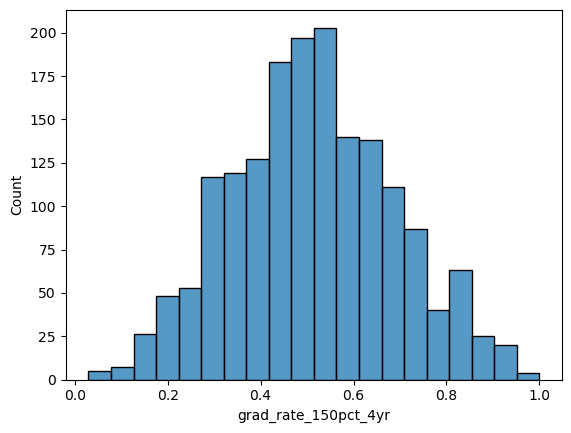

In [77]:
# Visualize the distribution of the target variable
sns.histplot(df["grad_rate_150pct_4yr"], bins=20)

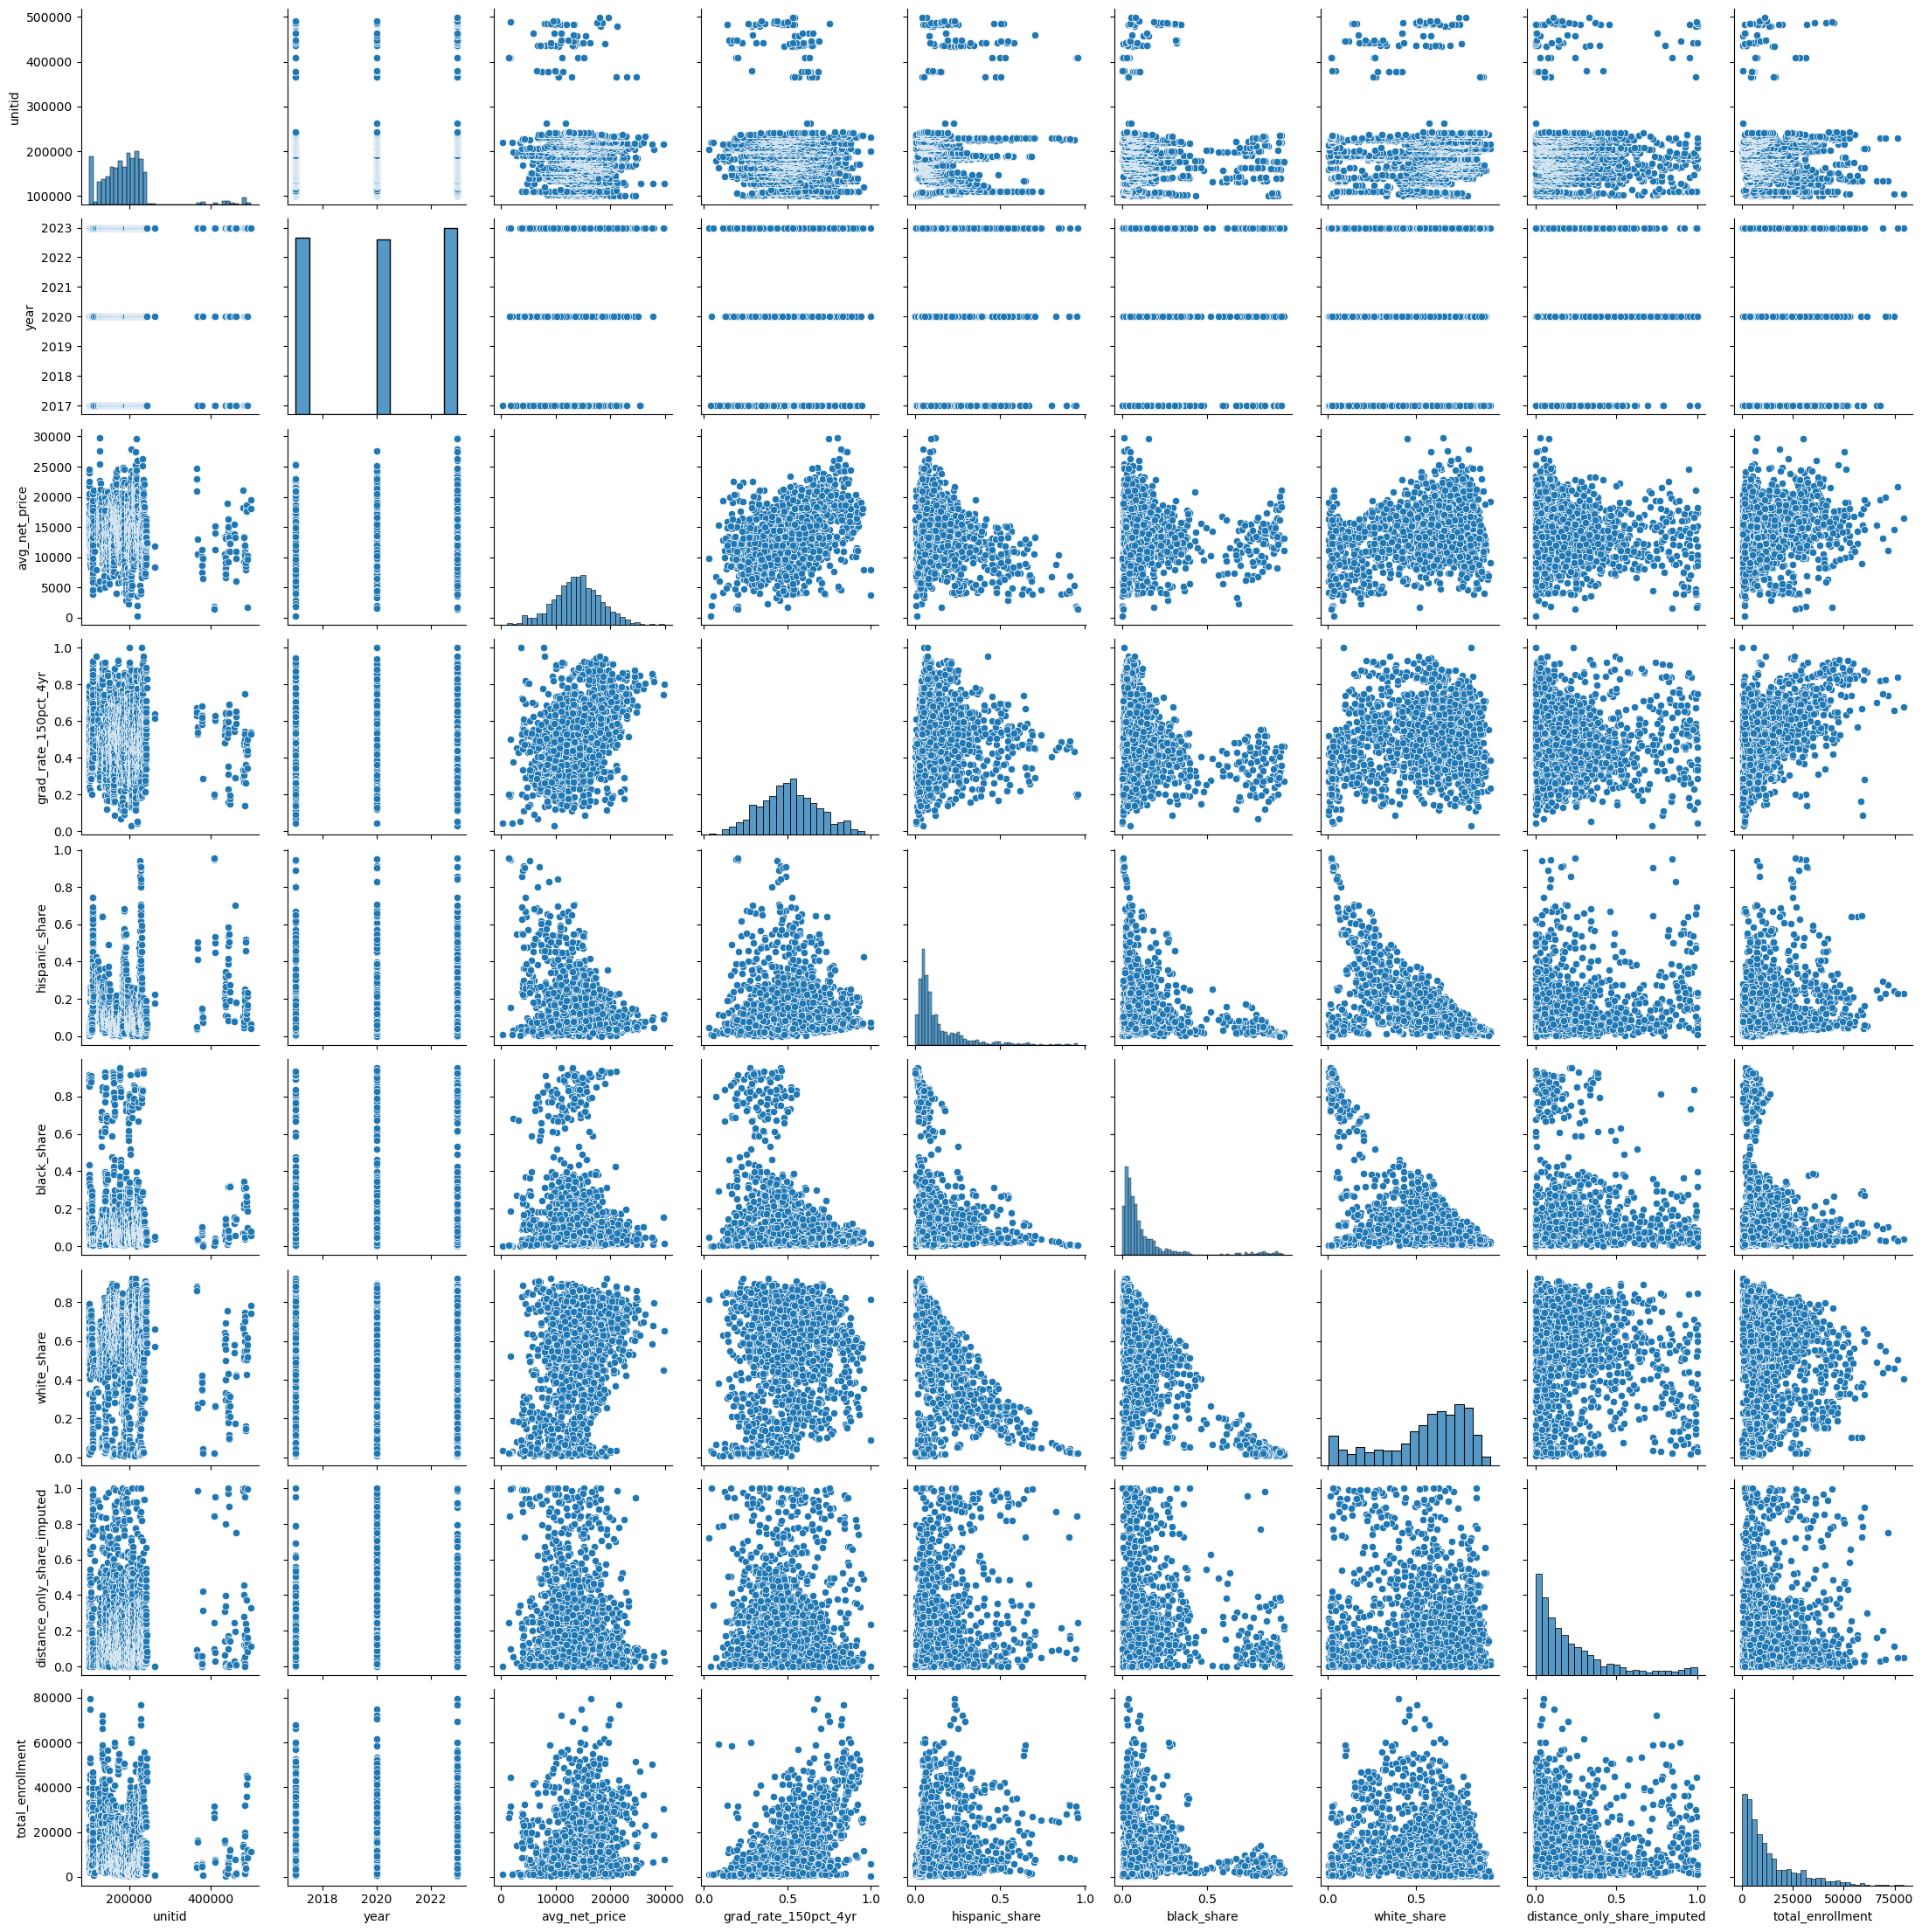

In [78]:
# Pairplot to visualize the relationships between features
sns.pairplot(data = df)

<Axes: >

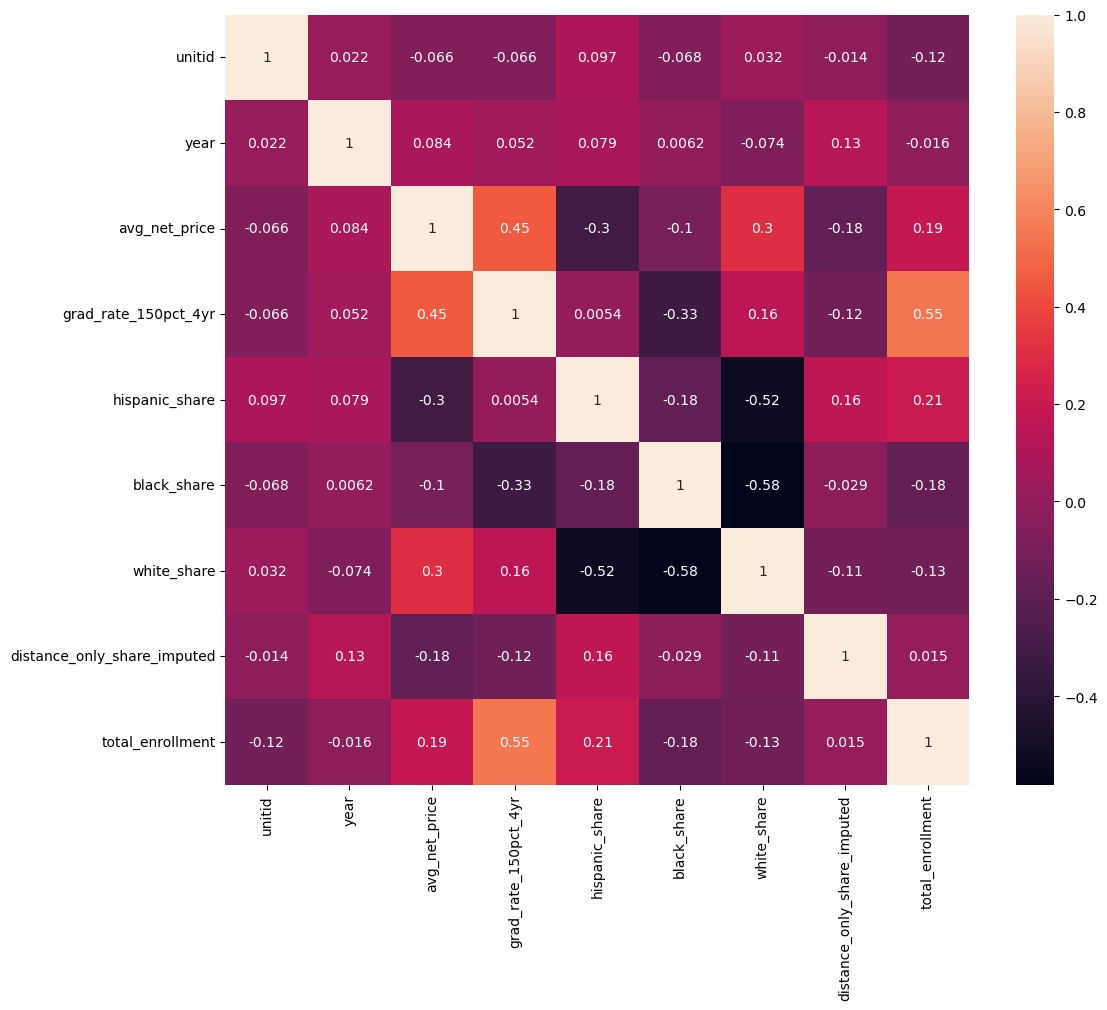

In [79]:
# Correlation matrix to visualize the relationships between features
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=["number"]).corr(), annot=True)

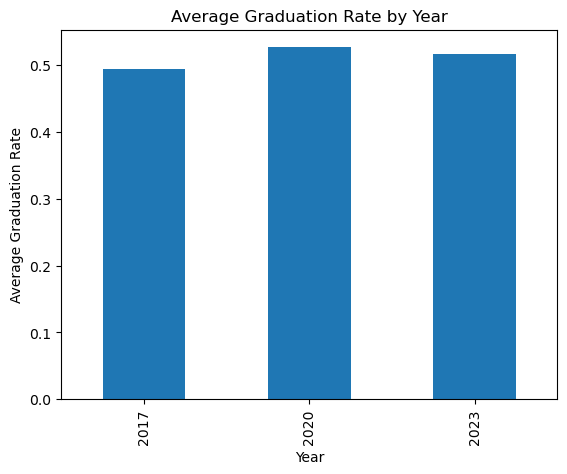

In [80]:
# Visualize the average graduation rate by year
df.groupby("year")["grad_rate_150pct_4yr"].mean().plot(kind="bar")
plt.title("Average Graduation Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Graduation Rate")
plt.show()

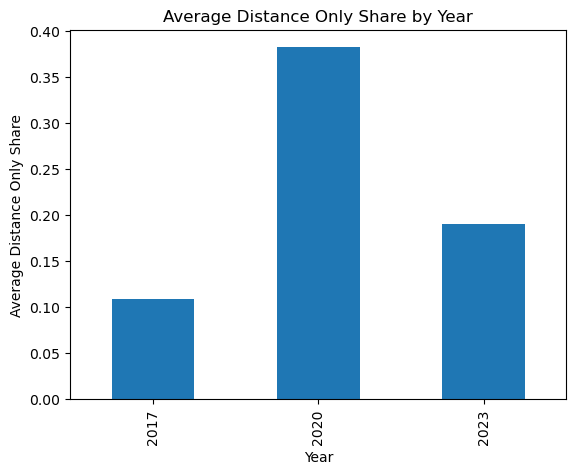

In [81]:
# Visualize the average distance only share by year
df.groupby("year")["distance_only_share_imputed"].mean().plot(kind="bar")
plt.title("Average Distance Only Share by Year")
plt.xlabel("Year")
plt.ylabel("Average Distance Only Share")
plt.show()

In [82]:
# Create a new datafram for HBCUs by filtering for institutions with a black share greater than 80% to find the number of HBCUs in the dataset
hbcu_df = df[df["black_share"] > 0.8]
hbcu_df.size

600

# Model Experiments

In [83]:
# Remove identifying columns for modeling purposes
model_df = scaled_df.drop(columns=["institution_name", "unitid"])

# Separate the target variable from the features
X = model_df.drop(columns = ["grad_rate_150pct_4yr"])
y = model_df["grad_rate_150pct_4yr"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=67)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (1370, 7)
X_test (343, 7)
y_train (1370,)
y_test (343,)


## Model 1: Multiple Regression Model without Race Share Variables

In [84]:
model1 = linear_model.LinearRegression()
model1.fit(X_train.drop(columns=["white_share", "black_share", "hispanic_share"]), y_train)

LinearRegression()

In [85]:
# Model 1 Evaluation
y_pred = model1.predict(X_test.drop(columns=["white_share", "black_share", "hispanic_share"]))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MSE: 0.5955538538281867
MAE: 0.5690910432805572
RMSE: 0.7717213576338202
R^2: 0.418284420126787


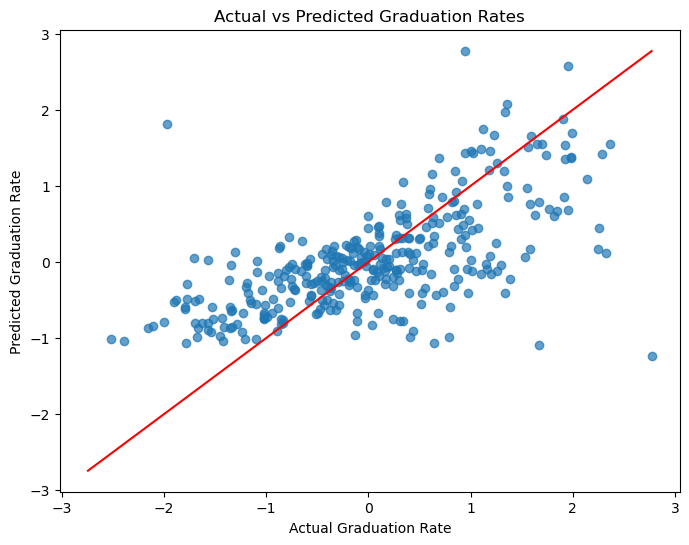

In [86]:
# Graph to visualize the relationship between actual and predicted values for model 1
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
plt.xlabel('Actual Graduation Rate')
plt.ylabel('Predicted Graduation Rate')
plt.title('Actual vs Predicted Graduation Rates')
plt.show()

## Model 2: Multiple Regression Model with Race Share Variables

In [87]:
model2 = linear_model.LinearRegression()
model2.fit(X_train, y_train)

LinearRegression()

In [88]:
# Model 2 Evaluation
y_pred = model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MSE: 0.5497669960321807
MAE: 0.5449504063265888
RMSE: 0.7414627408253099
R^2: 0.46300737567844386


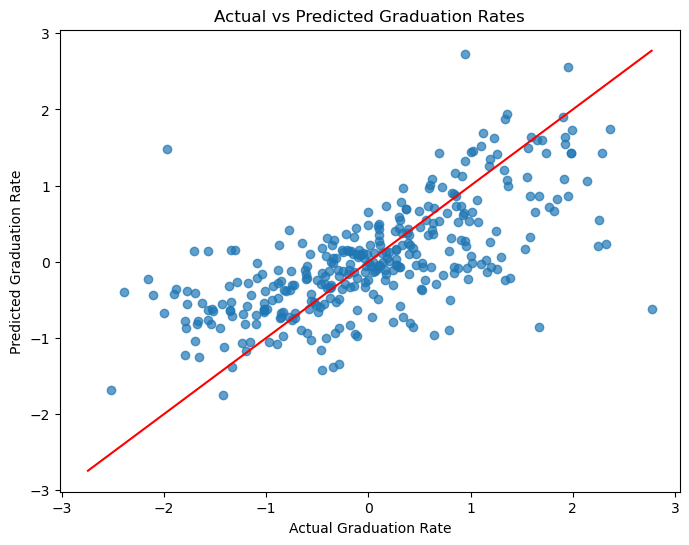

In [89]:
# Graph to visualize the relationship between actual and predicted values for model 2
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
plt.xlabel('Actual Graduation Rate')
plt.ylabel('Predicted Graduation Rate')
plt.title('Actual vs Predicted Graduation Rates')
plt.show()

## Model 3: Basic Decision Tree Regressor

In [90]:
model3 = DecisionTreeRegressor()
model3.fit(X_train, y_train)

DecisionTreeRegressor()

In [91]:
# Model 3 Evaluation
y_pred = model3.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MSE: 0.7065425770237701
MAE: 0.5964275337892663
RMSE: 0.8405608705047899
R^2: 0.3098746280347815


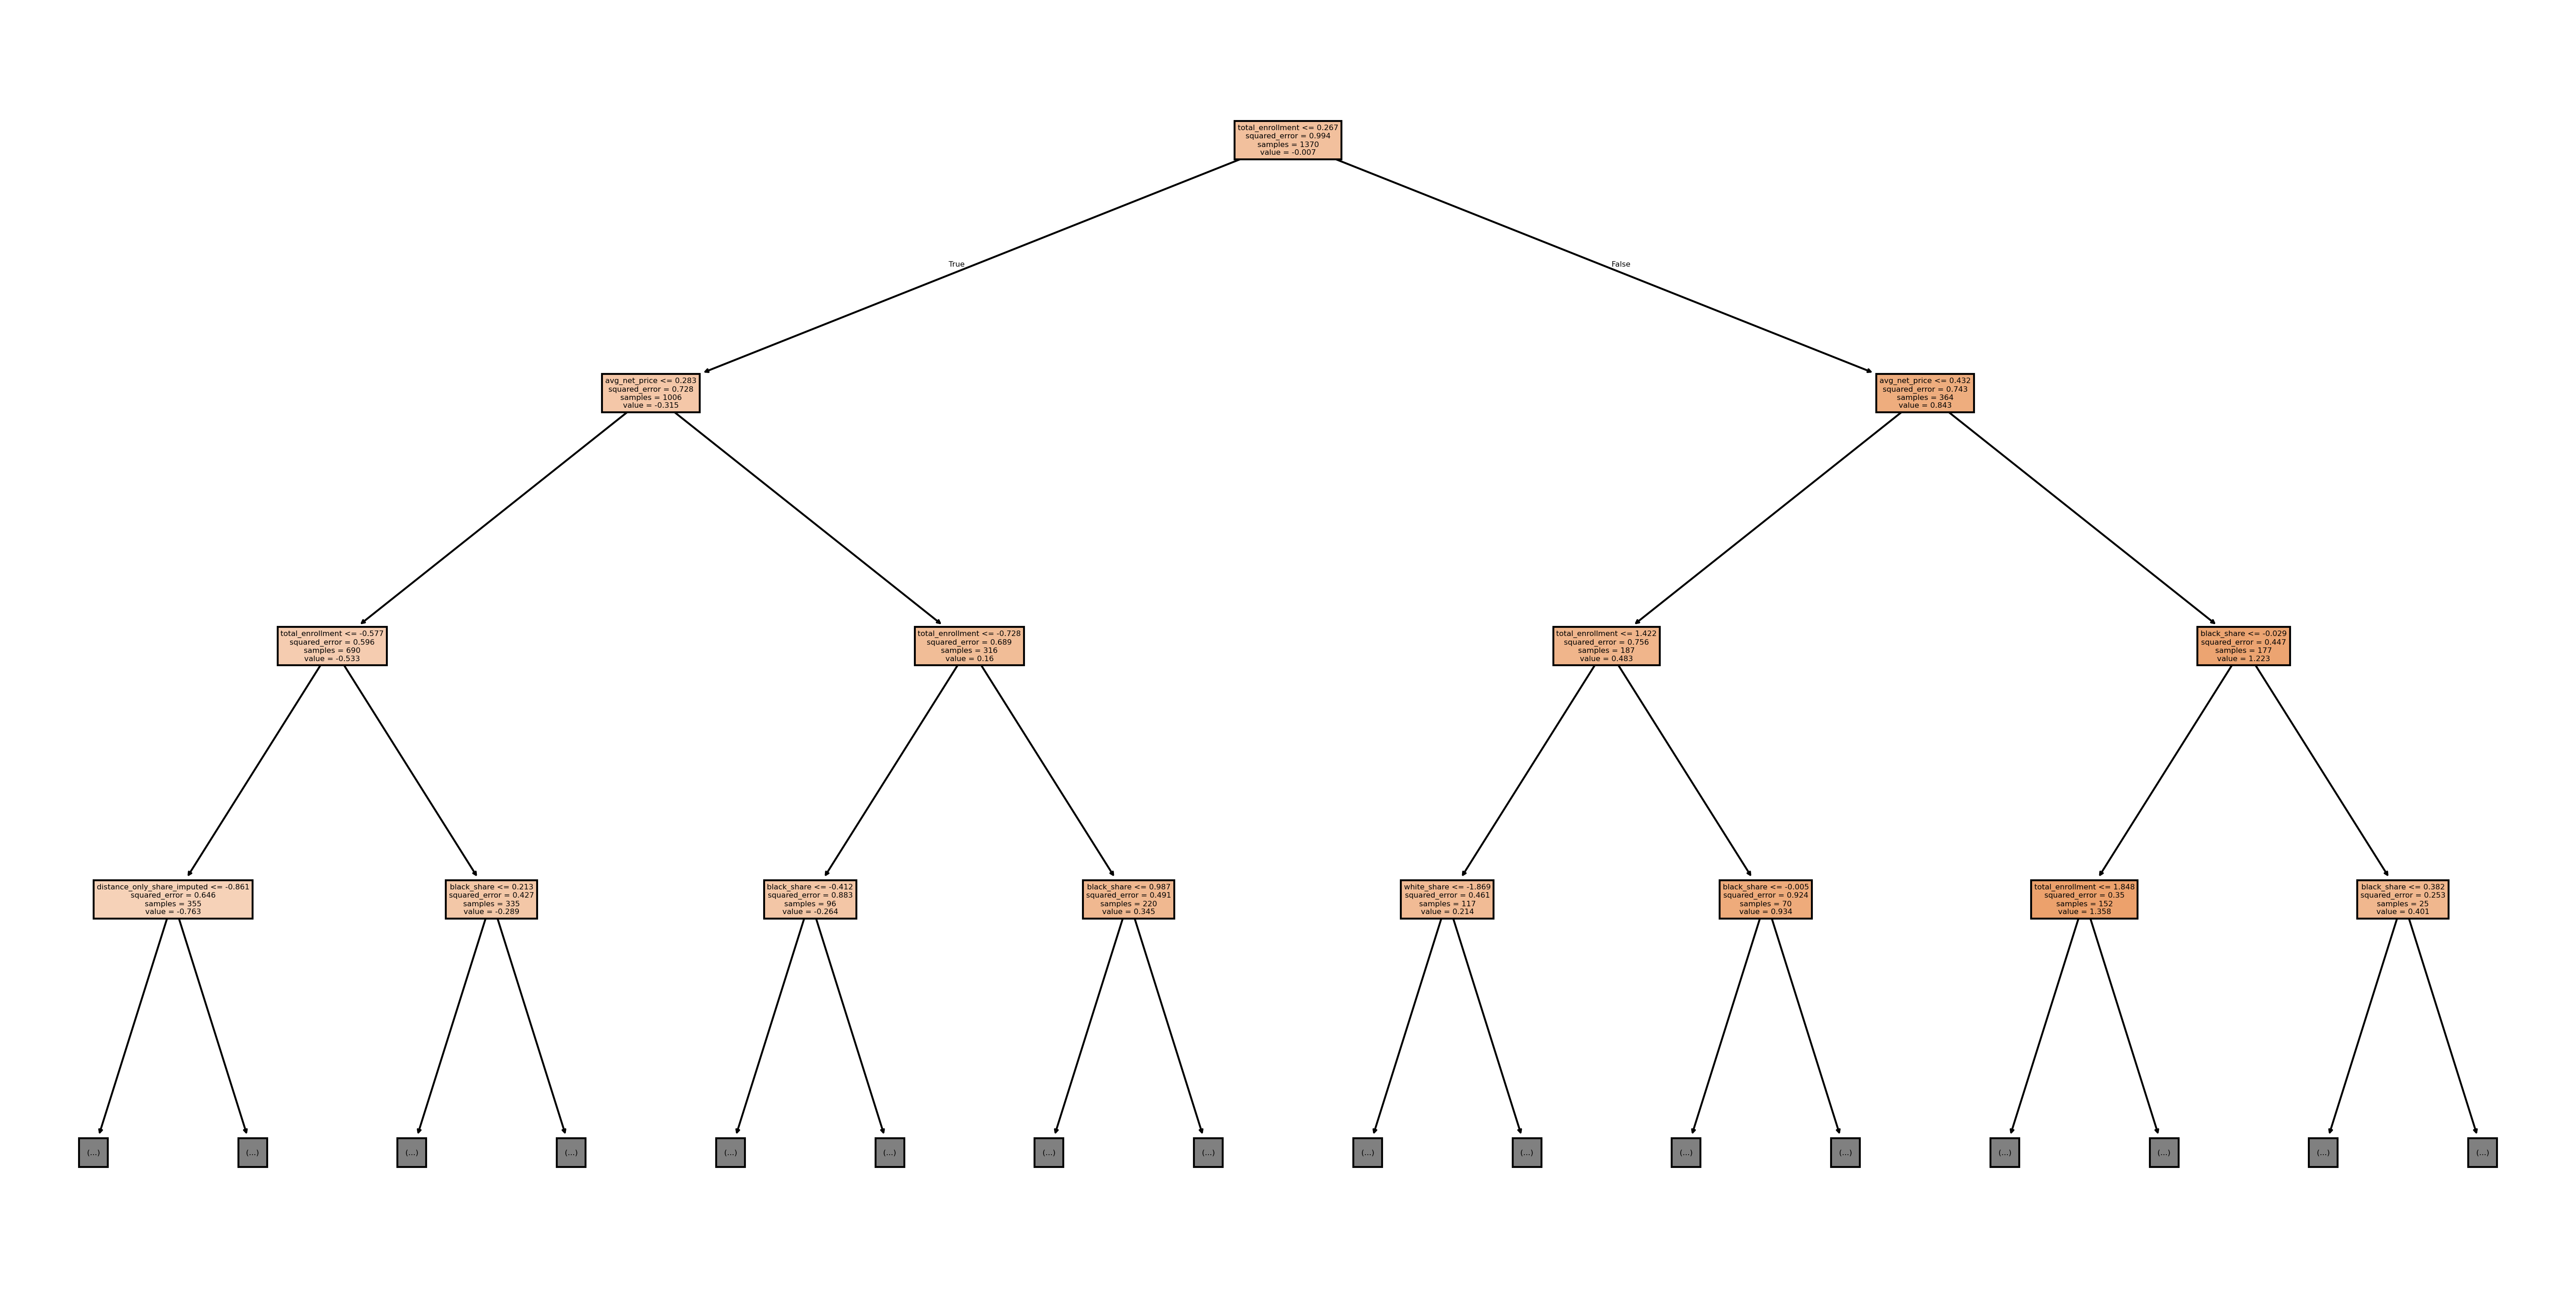

In [92]:
# View the decision tree
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (24,12), dpi=300)
tree.plot_tree(model3, max_depth = 3, feature_names = X.columns, filled=True)
plt.show()

/var/folders/gg/ygm3cw754d38t0620ldb3nhh0000gn/T/ipykernel_40539/4088312596.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


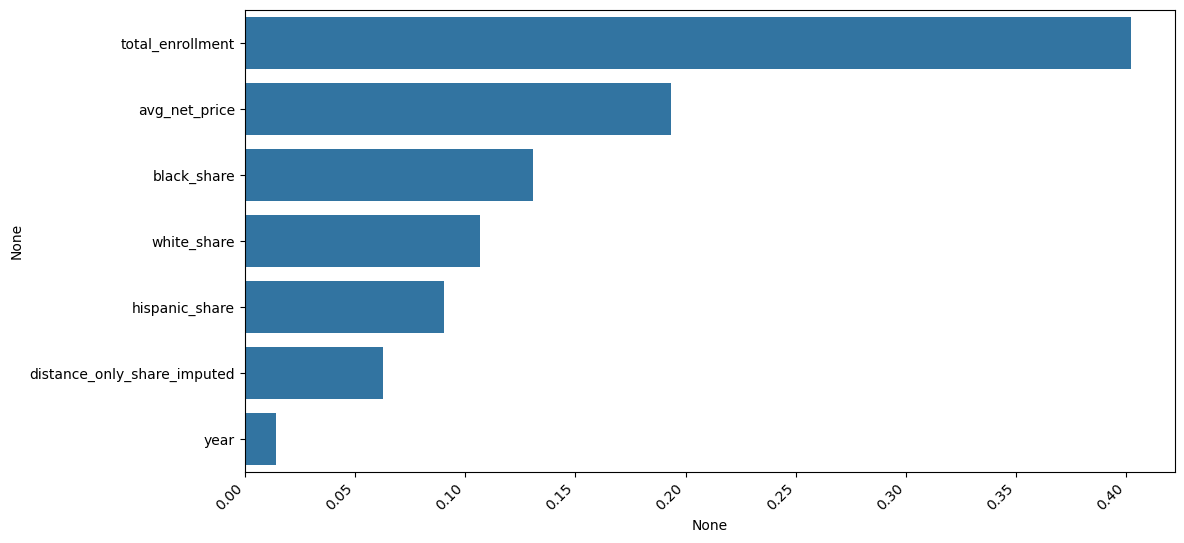

In [93]:
# Feature importance plot
fi = model3.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

## Model 4: Decision Tree Regressor with Hyperparameter Tuning

In [94]:
depths = [1, 2, 3, 4, 5, None]
criterion = ["squared_error", "friedman_mse", "absolute_error"]
splitters = ["best", "random"]
min_samples_splits = [2, 3, 4, 5, 6, 7, 8, 9, 10]
min_samples_leafs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
best_score = 0
best_params = None
for depth in depths:
    for criterions in criterion:
        for splitter in splitters:
            for min_samples_split in min_samples_splits:
                for min_samples_leaf in min_samples_leafs:
                            model = DecisionTreeRegressor(max_depth = depth, criterion = criterions, splitter = splitter, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf)
                            scores =  cross_val_score(model, X_train, y_train, cv = 5, scoring = "r2")
                            
                            # View all outputs for each combination of parameters
                            # print(f"Max depth: {depth}, Criterion: {criterions}, Splitter: {splitter}, Min samples split: {min_samples_split}, Min samples leaf: {min_samples_leaf}, Average r2: {scores.mean()}:.4f")
                            if scores.mean() > best_score:
                                best_score = scores.mean()
                                best_params = (depth, criterions, splitter, min_samples_split, min_samples_leaf)

print(f"Best params: Max depth: {best_params[0]}, Criterion: {best_params[1]}, Splitter: {best_params[2]}, Min samples split: {best_params[3]}, Min samples leaf: {best_params[4]}, Best r2 score: {best_score:.4f}")

Best params: Max depth: None, Criterion: friedman_mse, Splitter: random, Min samples split: 3, Min samples leaf: 6, Best r2 score: 0.4766


In [95]:
model4 = DecisionTreeRegressor(max_depth = best_params[0], criterion = best_params[1], splitter = best_params[2], min_samples_split = best_params[3], min_samples_leaf = best_params[4])
model4 = model4.fit(X_train, y_train)

In [96]:
# Model 4 Evaluation
y_pred = model4.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MSE: 0.4865144549678547
MAE: 0.5360187495887764
RMSE: 0.6975058816725883
R^2: 0.524790182333413


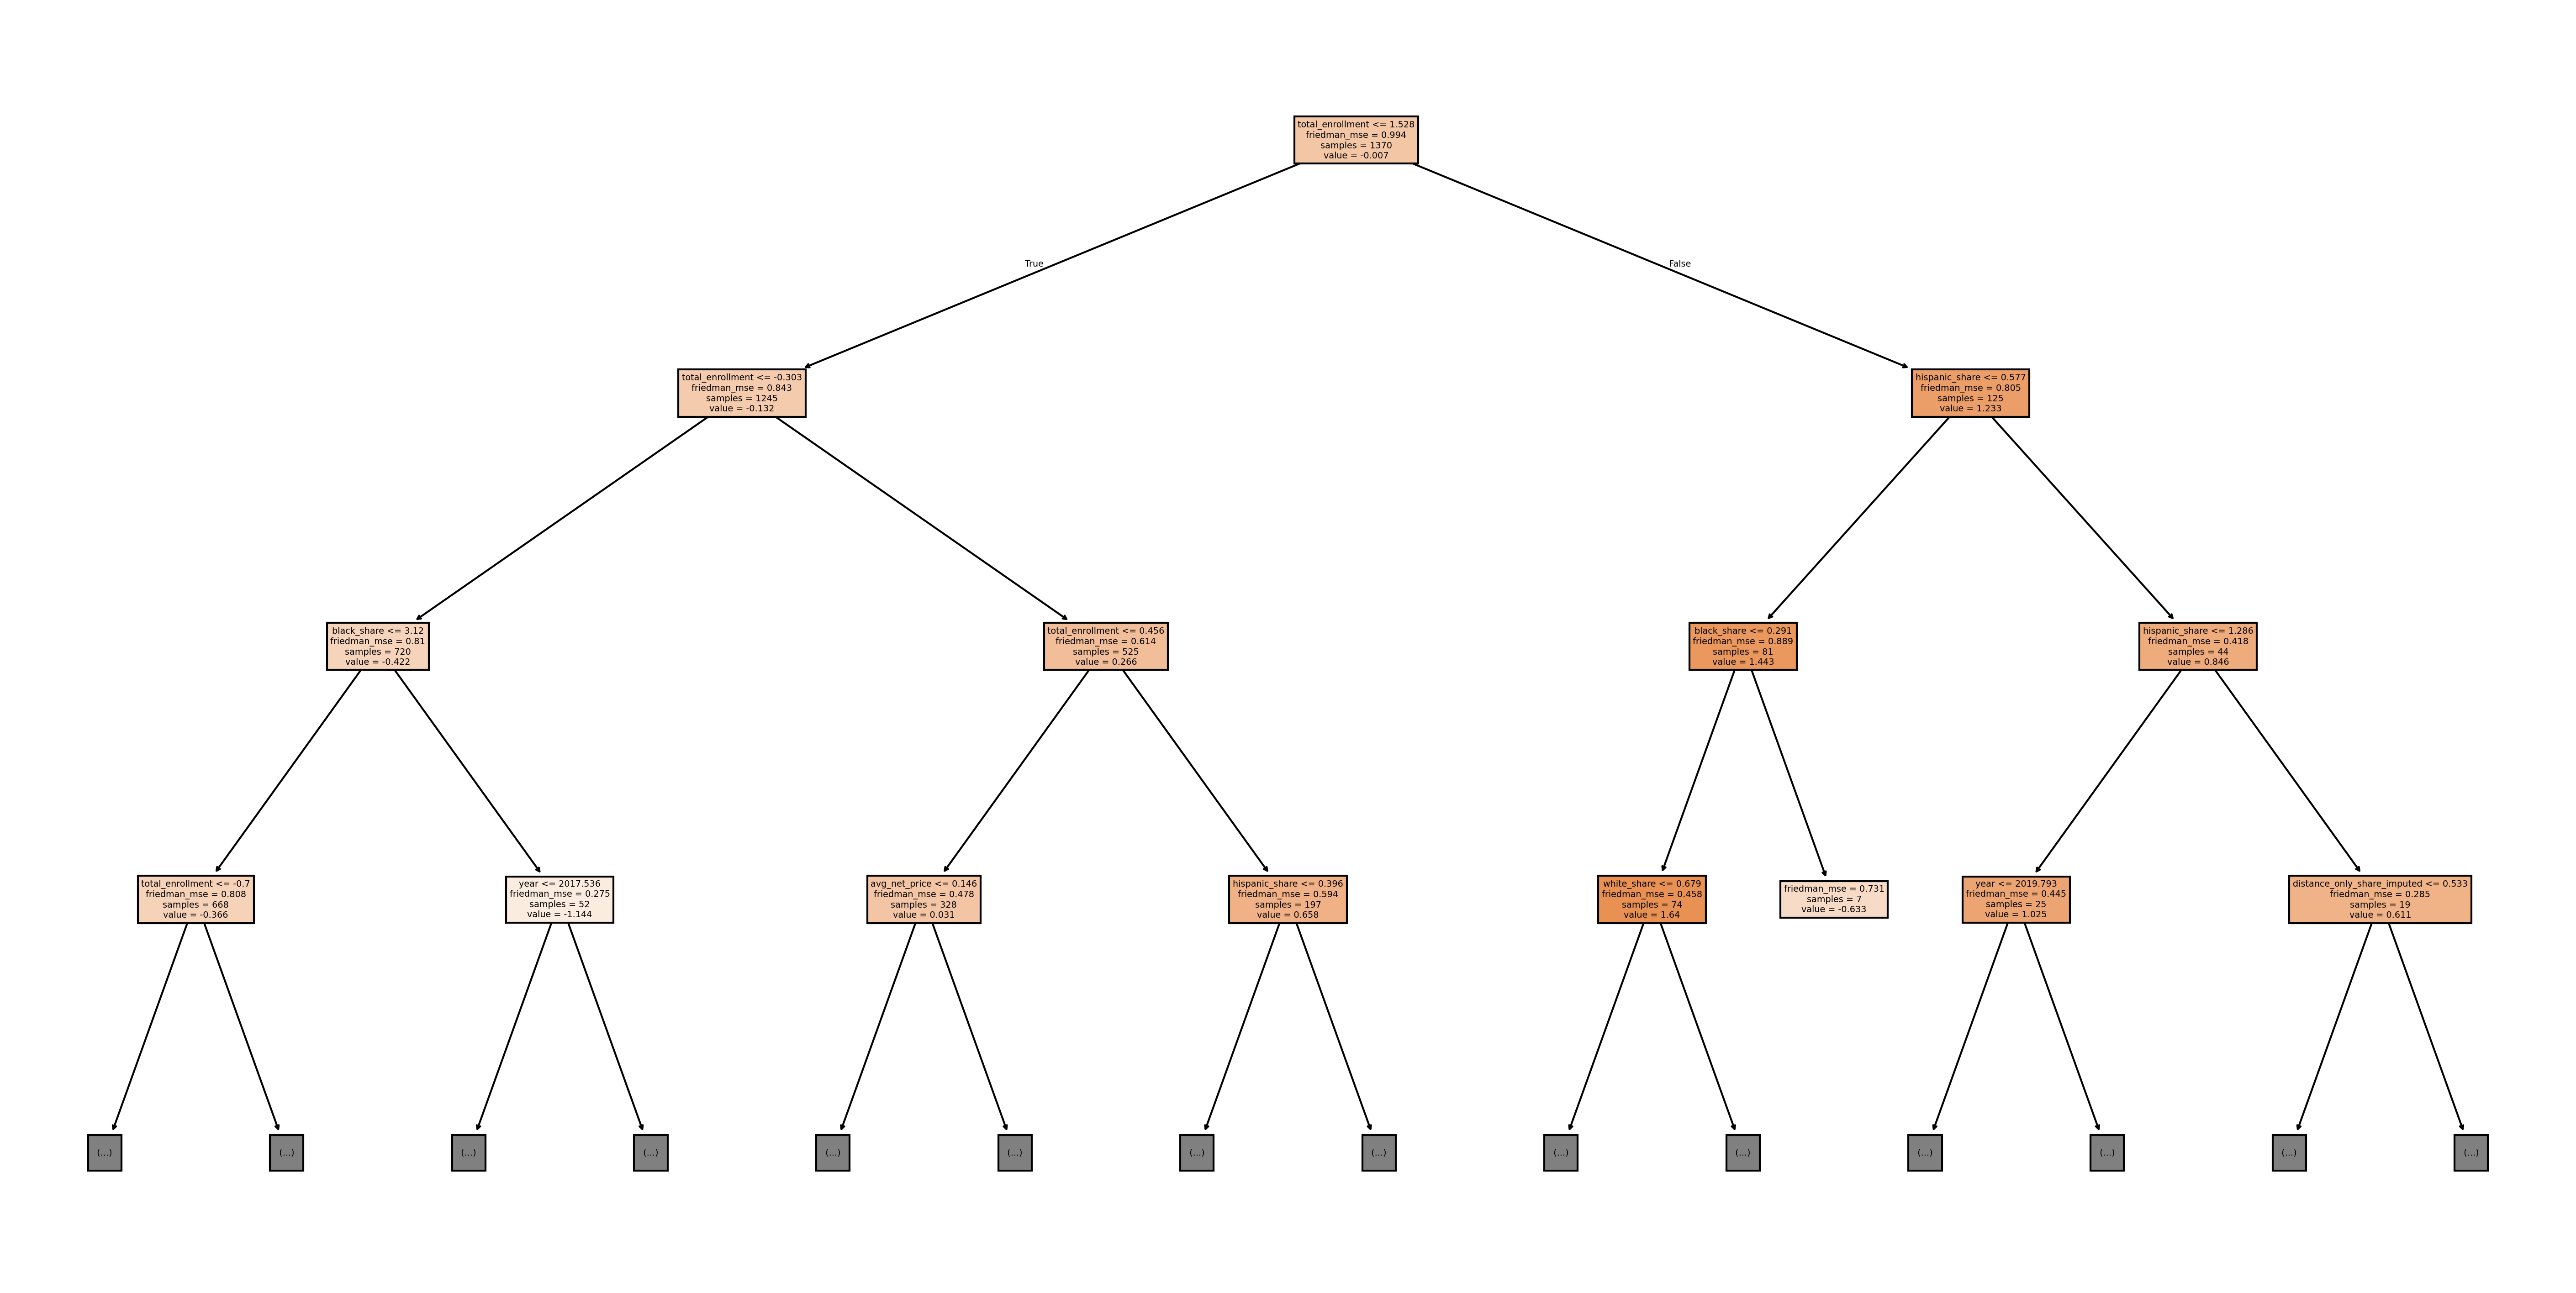

In [97]:
# View the decision tree
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (24,12), dpi=300)
tree.plot_tree(model4, max_depth = 3, feature_names = X.columns, filled=True)
plt.show()

/var/folders/gg/ygm3cw754d38t0620ldb3nhh0000gn/T/ipykernel_40539/3904627909.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


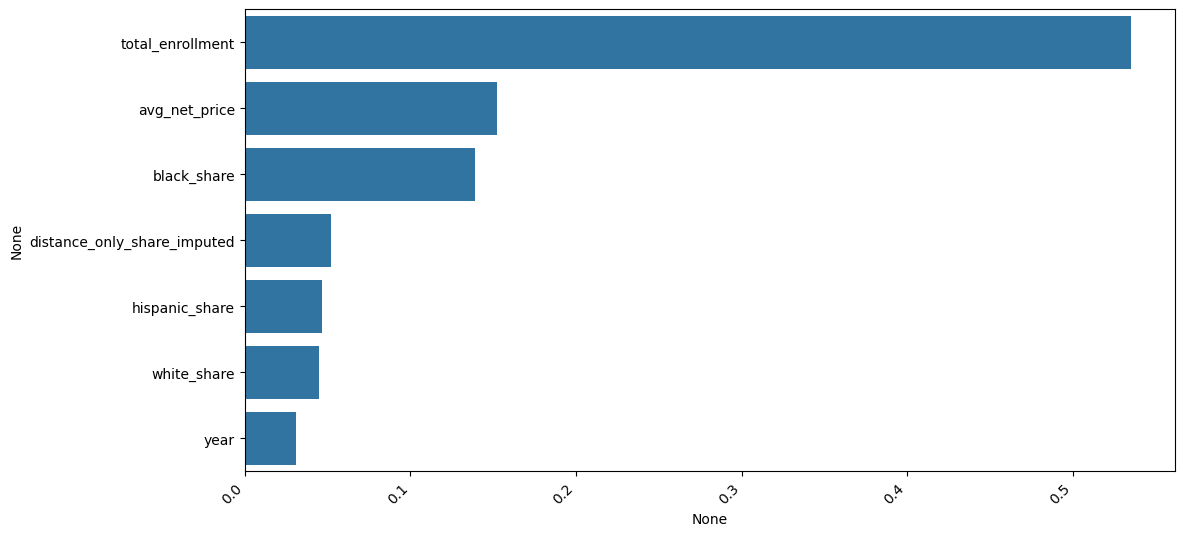

In [98]:
# Feature importance plot
fi = model4.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

## Model 5: Ridge Regression

In [99]:
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]
best_score = 0
best_alpha = None
for alpha_value in alpha_values:  
    model = Ridge(alpha=alpha_value)
    scores =  cross_val_score(model, X_train, y_train, cv = 5, scoring = "r2")
                            
    # View all outputs for each alpha value
    print(f"Alpha: {alpha_value}, Average r2: {scores.mean()}:.4f")
    if scores.mean() > best_score:
        best_score = scores.mean()
        best_alpha = alpha_value

print(f"Best alpha: {best_alpha}, Best r2 score: {best_score:.4f}")


Alpha: 0.01, Average r2: 0.4827350171358786:.4f
Alpha: 0.1, Average r2: 0.4827375845773509:.4f
Alpha: 1.0, Average r2: 0.4827623400895866:.4f
Alpha: 10.0, Average r2: 0.4829274345975282:.4f
Alpha: 100.0, Average r2: 0.4805827917059391:.4f
Alpha: 500.0, Average r2: 0.44844992263927735:.4f
Alpha: 1000.0, Average r2: 0.39944989995995395:.4f
Best alpha: 10.0, Best r2 score: 0.4829


In [100]:
model5 = Ridge(alpha = best_alpha)
model5.fit(X_train, y_train)

Ridge(alpha=10.0)

In [101]:
# Model 5 Evaluation
y_pred = model5.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MSE: 0.5494196468221049
MAE: 0.544804576273314
RMSE: 0.7412284714054802
R^2: 0.46334665389125196


In [102]:
df_coefficents = pd.DataFrame({"Feature": X_train.columns, "Coefficient": model5.coef_}) # create dataframe with feature names and coefficients
print(df_coefficents)

                       Feature  Coefficient
0                         year     0.013211
1                avg_net_price     0.318403
2               hispanic_share    -0.094979
3                  black_share    -0.302404
4                  white_share    -0.103733
5  distance_only_share_imputed    -0.072670
6             total_enrollment     0.453444


## Model 6: Random Forest Regressor

In [103]:
model6 = RandomForestRegressor(n_estimators=100)
model6.fit(X_train, y_train)

RandomForestRegressor()

In [104]:
# Model 6 Evaluation
y_pred = model6.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MSE: 0.3455961035028251
MAE: 0.44402104091706857
RMSE: 0.5878742242204749
R^2: 0.6624341586259517


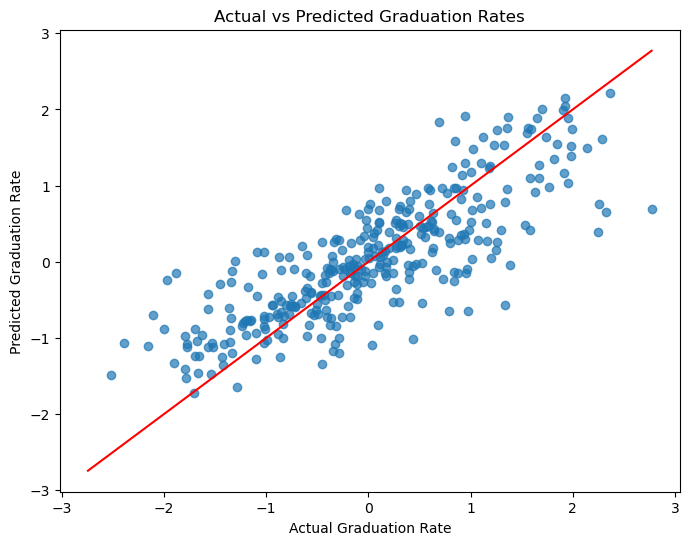

In [105]:
# Graph to visualize the relationship between actual and predicted values for model 6
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
plt.xlabel('Actual Graduation Rate')
plt.ylabel('Predicted Graduation Rate')
plt.title('Actual vs Predicted Graduation Rates')
plt.show()

/var/folders/gg/ygm3cw754d38t0620ldb3nhh0000gn/T/ipykernel_40539/3268979726.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


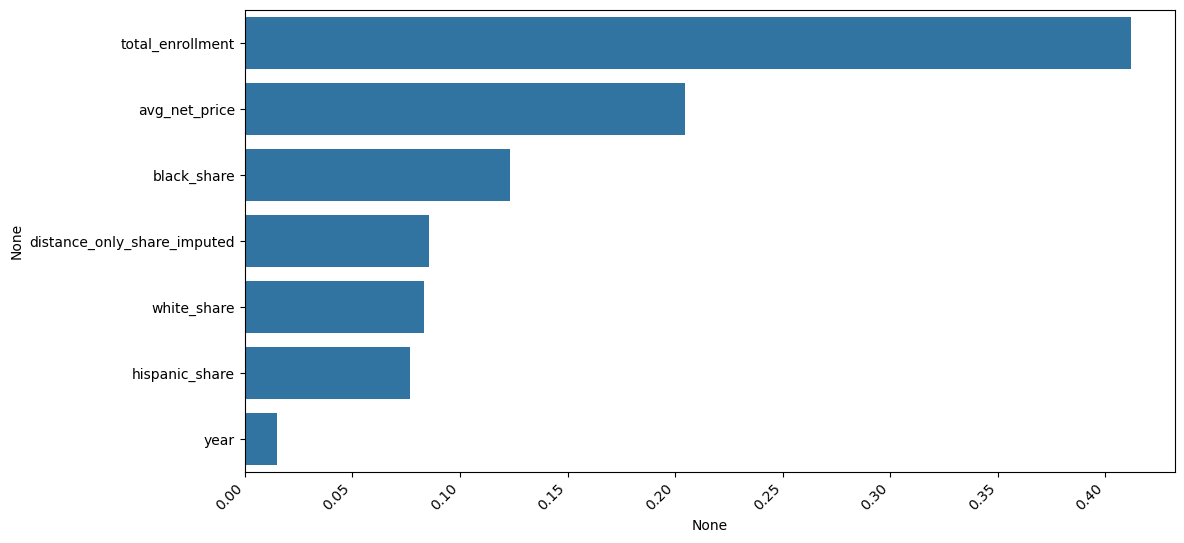

In [ ]:
# Feature importance plot for model 6
fi = model6.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending

#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

# References & AI Transparency
Portions of code were copied (and then edited) from previous in-class studio notes/assignments as well as the websites listed below. Additionally, GitHub Copilot was occasionally used to write code with its Inline Suggestions feature.

Data source: https://nces.ed.gov/ipeds/datacenter/InstitutionByName.aspx?goToReportId=1&sid=7375a633-6c6e-409e-9b04-9dbd88a26215&rtid=1

- Multiple Regression: https://www.w3schools.com/python/python_ml_multiple_regression.asp & Final Project from DTSC 1302
- Decision Tree Regressor: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
- Ridge Regression: https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/ & https://medium.com/@dvdhartsman/extracting-coefficients-and-feature-names-from-scikit-learn-pipelines-331d578b8450
- Random Forest Regressor: https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/ 